# Phần 2 — Lập lịch máy và phân ca

Dạng **Scheduling**: bài toán có chiều thời gian và thường có hàm mục tiêu tối ưu.
Đây là sân nhà của **biến interval** — cấu trúc dữ liệu mà CP Optimizer đã phát
triển chuyên biệt hơn 20 năm.

Hai bài trong phần này thuộc hai nhánh con khác nhau và cho thấy **thế mạnh của
hai engine nằm ở hai chỗ khác nhau**:

| Bài | Nhánh | Engine thắng | Vì sao |
|---|---|---|---|
| 2.1 Job-shop | machine scheduling | CP-SAT (ở cỡ nhỏ) | ít nhánh hơn 645 lần nhờ học mệnh đề |
| 2.2 Employee | personnel rostering | CP-SAT | `add_exactly_one` là nguyên hàm boolean, nạp thẳng thành CNF |

Bài 2.2 còn là một **khoảng trống của hệ IBM**: cả OPL lẫn `docplex.cp` đều không
có ví dụ chính thức nào cho bài xếp ca nhân sự bằng CP — bản `nurses` của IBM là
MILP, chạy trên engine CPLEX, khác paradigm. Bằng chứng cụ thể ở mục (c) của bài.

In [1]:
import sys; sys.path.insert(0, "../tools")
from nbutil import *
from nbviz import *

---

# Bài 2.1 — Job-shop scheduling (instance ft06)

## (a) Phát biểu bài toán

In [2]:
show_notes("2.1_jobshop", "Phát biểu")

## (a) Phát biểu bài toán

Có $n$ **job** (đơn hàng) phải gia công trên $m$ **máy**.

- Mỗi job gồm đúng $m$ **công đoạn** (operation), phải làm **theo đúng thứ tự đã
  định trước** — công đoạn sau chỉ được bắt đầu khi công đoạn trước đã xong. Thứ
  tự này gọi là *thứ tự công nghệ* (technological order) và là dữ liệu vào, không
  phải biến.
- Công đoạn thứ $o$ của job $j$ phải chạy trên đúng **một máy đã chỉ định** trong
  đúng **một khoảng thời gian đã biết**. Trong job-shop cổ điển, mỗi job đi qua
  **mỗi máy đúng một lần**.
- Một máy **chỉ gia công một công đoạn tại một thời điểm**.
- Công đoạn **không được ngắt quãng** (no preemption): đã khởi động thì chạy liền
  một mạch tới khi xong.
- Thời gian **không giới hạn trần**: mọi lịch đều khả thi nếu xếp tuần tự. Bài
  toán vì thế luôn có nghiệm — cái khó nằm ở chỗ **tối ưu**.

**Mục tiêu:** cực tiểu **makespan** — thời điểm công đoạn cuối cùng của toàn bộ
xưởng kết thúc.

Điều phải quyết định chỉ có một thứ: **thứ tự các công đoạn trên từng máy**. Khi
thứ tự đó đã chốt thì thời điểm bắt đầu sớm nhất tính được ngay. Đây là lý do
job-shop được xếp vào lớp **disjunctive scheduling**: mọi ràng buộc khó đều có
dạng "hoặc $A$ trước $B$, hoặc $B$ trước $A$".

### Instance dùng trong bài: `ft06`

`ft06` là instance chuẩn của Fisher & Thompson (1963), $6\times 6$, có mặt trong
mọi bộ benchmark job-shop (OR-Library). **Makespan tối ưu đã biết: 55.** Con số
này biến bài thành một **phép thử đúng/sai tuyệt đối** cho cả ba chiều — chạy ra
55 thì mô hình đúng, ra khác 55 thì mô hình sai, không phải bàn thêm.

| Đại lượng | Giá trị |
|---|---|
| Số job × số máy | $6\times 6$ = 36 công đoạn |
| Tổng thời gian gia công | 197 |
| Tải từng máy $M_0..M_5$ | 40, 26, 26, 22, 40, 43 |
| Tải từng job $J_0..J_5$ | 26, 47, 34, 35, 25, 30 |
| Chặn dưới tầm thường $\max(\max_m L_m,\ \max_j P_j)$ | **47** |
| Tối ưu thật | **55** |
| Số lịch tích cực tối đa $(n!)^m$ | $720^6 \approx 1.39\times10^{17} = 2^{56.95}$ |

Hai điều rút ra từ bảng: (1) chặn dưới tầm thường **cách tối ưu 8 đơn vị**, tức
instance không tầm thường — đây chính là lý do ft06 sống dai trong tài liệu suốt
60 năm; (2) không gian tìm kiếm $2^{57}$ nằm **rất sâu dưới trần $2^{1000}$** của
CPLEX Studio Community Edition, nên bài này không vướng giới hạn giấy phép
(xem `PLAN.md` §2.1).

---

## (b) Mô hình toán học

Mô hình dưới đây là **hợp đồng chung** mà cả ba chiều cùng cài đặt. Ba đoạn code ở mục (c) chỉ là ba cách diễn đạt đúng mô hình này.

In [3]:
show_notes("2.1_jobshop", "Mô hình toán")

## (b) Mô hình toán học — DÙNG CHUNG cho cả ba chiều

> Mô hình dưới đây mô tả đúng những gì cả ba bản cài đặt làm. Cả ba dùng **cùng
> một cách mã hoá — biến interval** — nên khác với bài 3.2 (nơi ba chiều mã hoá
> ba kiểu), ở bài này biến số duy nhất bị đổi là **ngôn ngữ** rồi **engine**.

### Tập hợp

| Ký hiệu | Ý nghĩa |
|---|---|
| $\mathcal{J}=\{0,\dots,n-1\}$ | tập job |
| $\mathcal{M}=\{0,\dots,m-1\}$ | tập máy |
| $\mathcal{O}=\{0,\dots,m-1\}$ | vị trí công đoạn trong một job (job-shop cổ điển: mỗi job có đúng $m$ công đoạn) |
| $\mathcal{I}=\mathcal{J}\times\mathcal{O}$ | tập **công đoạn**; phần tử $i=(j,o)$ |
| $\mathcal{I}_m=\{\,i\in\mathcal{I}\ :\ \mu_i=m\,\}$ | các công đoạn chạy trên máy $m$ |

### Tham số

| Ký hiệu | Miền | Ý nghĩa |
|---|---|---|
| $\mu_{j,o}$ | $\mathcal{M}$ | máy thực hiện công đoạn thứ $o$ của job $j$ |
| $p_{j,o}$ | $\mathbb{Z}_{>0}$ | thời gian gia công công đoạn đó |
| $H$ | $\mathbb{Z}_{>0}$ | horizon, chặn trên hiển nhiên của makespan |

Ràng buộc trên **dữ liệu vào** (không phải ràng buộc của mô hình): với mỗi
$j\in\mathcal{J}$, ánh xạ $o\mapsto\mu_{j,o}$ là **song ánh** $\mathcal{O}\to\mathcal{M}$
— mỗi job đi qua mỗi máy đúng một lần. Hệ quả: $|\mathcal{I}_m| = n$ với mọi máy $m$.

$$H \;=\; \sum_{j\in\mathcal{J}}\sum_{o\in\mathcal{O}} p_{j,o}
\qquad(\text{xếp tuần tự mọi công đoạn thì chắc chắn xong trước } H)$$

Với ft06: $n=m=6$, $H=197$.

### Biến quyết định

Biến chính của bài này là **biến interval** ($\texttt{intervalVar}$ trong CP
Optimizer, $\texttt{new\_interval\_var}$ trong CP-SAT) — một kiểu biến **không có
trong lập trình tuyến tính** và là đặc sản của CP dành cho lập lịch. Một biến
interval $x_i$ đại diện cho **cả một khoảng thời gian** $[\sigma_i,\eta_i)$ chứ
không phải một con số, và mang sẵn ba đại lượng liên kết:

| Biến | Miền | Ý nghĩa |
|---|---|---|
| $x_{j,o}$ | **interval** | công đoạn $(j,o)$, coi như một khối đặc trên trục thời gian |
| $\sigma_{j,o}=\operatorname{startOf}(x_{j,o})$ | $\{0,\dots,H\}$ | thời điểm bắt đầu |
| $\eta_{j,o}=\operatorname{endOf}(x_{j,o})$ | $\{0,\dots,H\}$ | thời điểm kết thúc (hở phải) |
| $\pi_m$ | **sequence** trên $\mathcal{I}_m$ | thứ tự các công đoạn trên máy $m$ (một hoán vị của $\mathcal{I}_m$) |
| $\omega$ | $\{0,\dots,H\}$ | makespan |

Ba ghi chú về khai báo biến — đều là nét đặc trưng của CP:

1. **Kích thước dán thẳng vào khai báo biến.** Cả ba chiều khai báo
   $x_{j,o}$ với `size` $=p_{j,o}$, nên ràng buộc "công đoạn dài đúng $p$ và
   không ngắt quãng" **đã nằm trong kiểu của biến**, không cần viết ra. Giống hệt
   thủ pháp đã gặp ở bài 3.2 khi thu miền của $\theta_i$ về $\mathcal{T}_{s_i}$.
2. **$\pi_m$ là biến hoán vị, không phải biến số.** OPL khai báo nó tường minh
   (`dvar sequence`); hai chiều Python để engine tự sinh khi gặp `no_overlap`.
   Mô hình toán viết ra ở đây để nói rõ *cái đang được quyết định thực chất là gì*.
3. **Máy KHÔNG phải biến.** $\mu_{j,o}$ là tham số. Đây là điểm phân biệt job-shop
   cổ điển với *flexible* job-shop (nơi máy trở thành biến, và cần
   `alternative`/optional interval như bài 3.2 dùng).

### Ràng buộc

**(C1) Cấu trúc của biến interval** — khai báo `size` đã bao hàm:

$$\eta_{j,o} \;=\; \sigma_{j,o} + p_{j,o}
\qquad \forall (j,o)\in\mathcal{I}$$

**(C2) Thứ tự công nghệ trong từng job** (*precedence* — `endBeforeStart`):

$$\eta_{j,o} \;\le\; \sigma_{j,\,o+1}
\qquad \forall j\in\mathcal{J},\ \forall o\in\{0,\dots,m-2\}
\tag{C2}$$

Đọc là: *công đoạn $o$ phải KẾT THÚC trước khi công đoạn $o+1$ BẮT ĐẦU.* Cả ba
chiều sinh đúng $n(m-1)=30$ ràng buộc loại này cho ft06.

**(C3) Một máy chỉ chạy một công đoạn tại một thời điểm** (*no-overlap*):

$$[\sigma_i,\eta_i)\ \cap\ [\sigma_{i'},\eta_{i'}) \;=\; \varnothing
\qquad \forall m\in\mathcal{M},\ \forall i\ne i' \in \mathcal{I}_m
\tag{C3}$$

Dạng **tuyển** (đây là chỗ sinh ra độ khó của bài toán):

$$\bigl(\eta_i \le \sigma_{i'}\bigr)\ \ \vee\ \ \bigl(\eta_{i'} \le \sigma_i\bigr)
\qquad \forall m,\ \forall i\ne i'\in\mathcal{I}_m
\tag{C3$'$}$$

Với ft06 có $m\cdot\binom{n}{2} = 6\cdot 15 = 90$ cặp tuyển như vậy — tức
$2^{90}$ tổ hợp hướng nếu duyệt mù. Cả ba chiều **không** viết (C3′) ra thành
tuyển: chúng gọi ràng buộc toàn cục `noOverlap` / `no_overlap` / `add_no_overlap`,
để engine tự cài thuật toán lan truyền chuyên dụng (edge-finding, not-first/not-last).
Đây chính là điểm mạnh của CP so với MILP ở lớp bài này.

Dạng tương đương qua biến thứ tự $\pi_m$ — cách OPL nhìn (C3):

$$\pi_m\ \text{là một hoán vị của } \mathcal{I}_m, \qquad
\eta_{\pi_m(k)} \le \sigma_{\pi_m(k+1)}\quad \forall k
\tag{C3$''$}$$

**(C4) Định nghĩa makespan.** Nhờ (C2), công đoạn cuối của mỗi job cũng là công
đoạn kết thúc muộn nhất của job đó, nên chỉ cần lấy max trên $m-1$:

$$\omega \;=\; \max_{j\in\mathcal{J}}\ \eta_{j,\,m-1}
\tag{C4}$$

**(C5) Miền:**

$$\sigma_{j,o}\ \ge\ 0 \qquad \forall (j,o)\in\mathcal{I}
\tag{C5}$$

### Hàm mục tiêu

$$\boxed{\ \min\ \omega\ }$$

### Chặn dưới hợp lệ (không cài đặt, dùng để kiểm chứng)

$$\omega \ \ge\ \max\Bigl(\ \max_{m\in\mathcal{M}} \sum_{i\in\mathcal{I}_m} p_i,\ \
\max_{j\in\mathcal{J}} \sum_{o\in\mathcal{O}} p_{j,o}\ \Bigr)$$

Vế đầu: máy $m$ phải chạy hết tải của nó mà không chồng lấn (C3). Vế sau: job $j$
phải chạy hết chuỗi công đoạn của nó một cách tuần tự (C2). Với ft06 chặn này
bằng **47**, còn tối ưu là **55** — cho thấy phần khó thật sự nằm ở **tương tác**
giữa (C2) và (C3), thứ mà không chặn dưới đơn lẻ nào bắt được.

### Bảng đối chiếu: mô hình toán ↔ ba chiều cài đặt

| | OPL | DOcplex.cp | OR-Tools |
|---|---|---|---|
| $x_{j,o}$ | `dvar interval itvs[j][o] size Ops[j][o].pt` | `interval_var(size=DURATION[j][m])` | `new_interval_var(s, d, e, name)` |
| $\pi_m$ | `dvar sequence mchs[m] in all(...)` | *(ngầm, do `no_overlap` sinh)* | *(ngầm, do `add_no_overlap` sinh)* |
| (C2) | `endBeforeStart(itvs[j][o], itvs[j][o+1])` | `end_before_start(op[j][s-1], op[j][s])` | `model.add(start[j,o] >= end[j,o-1])` |
| (C3) | `noOverlap(mchs[m])` | `no_overlap(mops)` | `add_no_overlap([...])` |
| (C4)+mục tiêu | `minimize max(j in Jobs) endOf(itvs[j][nbMchs-1])` | `minimize(max(end_of(...)))` | `add_max_equality(mk, [...])` + `minimize(mk)` |
| (C5)/horizon | ngầm (miền mặc định của interval) | ngầm | **tường minh**: `new_int_var(0, H-d, ...)` |

---

## (c) Cài đặt ba chiều

### OPL → engine CP Optimizer

In [4]:
show_dimension_code("2.1_jobshop", "opl")

**OPL → engine CP Optimizer · ✅ mẫu chính thức**

```opl
/* Bài 2.1 — Job-shop scheduling | Chiều OPL (engine CP Optimizer)
 *
 * Nguồn: LẤY MẪU CHÍNH THỨC.
 *   IBM ILOG CPLEX Optimization Studio 22.2 — opl/examples/opl/sched_jobshop/sched_jobshop.mod
 *   Licensed Materials - Property of IBM
 *   5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55
 *   Copyright IBM Corporation 1998, 2026. All Rights Reserved.
 *
 * Phần DỰNG MÔ HÌNH (khai báo dữ liệu, dvar interval, dvar sequence, minimize,
 * subject to) giữ NGUYÊN VĂN bản gốc của IBM — không đổi một ký tự.
 * Bổ sung duy nhất: khối execute EMIT_RESULT ở cuối, in dòng RESULT theo giao
 * kèo của tools/runner.py.
 *
 * Dữ liệu: đổi từ sched_jobshop.dat (một instance 6x6 KHÁC) sang data/jobshop/ft06.dat
 * để cả ba chiều chạy đúng cùng một instance — xem NOTES.md mục (c).
 *
 * Chạy:  tools/oplrun.sh models/2.1_jobshop/opl/sched_jobshop.mod data/jobshop/ft06.dat
 *
 * GHI CHÚ NGÔN NGỮ (điểm so sánh với DOcplex.cp — cùng engine CP Optimizer):
 *   OPL có kiểu `dvar sequence` như một CÔNG DÂN HẠNG NHẤT của ngôn ngữ: khai báo
 *   `dvar sequence mchs[m] in all(...) itvs[j][o]` vừa gom nhóm các interval chạy
 *   trên cùng một máy, vừa tạo ra một biến thứ tự dùng lại được. Bản DOcplex.cp
 *   không có cú pháp khai báo tương ứng — nó phải gom nhóm bằng vòng lặp Python
 *   rồi gọi no_overlap(danh_sách). Cùng engine, cùng ràng buộc, khác cách viết.
 */

using CP;

int nbJobs = ...;
int nbMchs = ...;

range Jobs = 0..nbJobs-1;
range Mchs = 0..nbMchs-1;
// Mchs is used both to index machines and operation position in job

tuple Operation {
  int mch; // Machine
  int pt;  // Processing time
};

Operation Ops[j in Jobs][m in Mchs] = ...;

dvar interval itvs[j in Jobs][o in Mchs] size Ops[j][o].pt;
dvar sequence mchs[m in Mchs] in all(j in Jobs, o in Mchs : Ops[j][o].mch == m) itvs[j][o];

execute {
  		cp.param.FailLimit = 10000;
}

minimize max(j in Jobs) endOf(itvs[j][nbMchs-1]);
subject to {
  forall (m in Mchs)
    noOverlap(mchs[m]);
  forall (j in Jobs, o in 0..nbMchs-2)
    endBeforeStart(itvs[j][o], itvs[j][o+1]);
}

execute {
  for (var j = 0; j <= nbJobs-1; j++) {
    for (var o = 0; o <= nbMchs-1; o++) {
      write(itvs[j][o].start + " ");
    }
    writeln("");
  }
}

// ===== BỔ SUNG — dòng RESULT theo giao kèo của tools/runner.py =====
// Chỉ đọc lời giải rồi in, không đụng tới mô hình.
// Lưu ý: card() không dùng được trong execute, nên số công đoạn tính bằng nhân.
execute EMIT_RESULT {
  var makespan = 0;
  for (var j = 0; j <= nbJobs-1; j++) {
    var e = itvs[j][nbMchs-1].end;
    if (e > makespan) makespan = e;
  }
  // FailLimit = 10000 (dòng cấu hình engine của bản gốc IBM) có thể khiến search
  // dừng trước khi chứng minh tối ưu. Chỉ khai "Optimal" khi search kết thúc tự
  // nhiên, tức số fails chưa chạm trần.
  var proven = (cp.info.numberOfFails < cp.param.FailLimit);
  writeln("RESULT {\"status\":\"" + (proven ? "Optimal" : "Feasible") + "\""
        + ",\"objective\":" + makespan
        + ",\"solve_time_s\":" + cp.info.solveTime
        + ",\"branches\":" + cp.info.numberOfBranches
        + ",\"fails\":" + cp.info.numberOfFails
        + ",\"nb_jobs\":" + nbJobs
        + ",\"nb_machines\":" + nbMchs
        + ",\"nb_operations\":" + (nbJobs * nbMchs) + "}");
}
```

### DOcplex.cp → engine CP Optimizer

In [5]:
show_dimension_code("2.1_jobshop", "docplexcp")

**Python (docplex.cp) → engine CP Optimizer · ✅ mẫu chính thức**

```python
"""Bài 2.1 — Job-shop scheduling | Chiều DOcplex.cp (engine CP Optimizer)

Nguồn: LẤY MẪU CHÍNH THỨC.
  IBMDecisionOptimization/docplex — examples/cp/visu/job_shop_basic.py
  Source file provided under Apache License, Version 2.0, January 2004,
  http://www.apache.org/licenses/
  (c) Copyright IBM Corp. 2015, 2022

Phần DỰNG MÔ HÌNH (interval_var / end_before_start / no_overlap / minimize) giữ
NGUYÊN VĂN bản gốc của IBM. Bổ sung:
  - đọc dữ liệu từ data/jobshop/ft06.dat — cùng một file với chiều OPL, thay cho
    file jobshop_ft06.data riêng của bản gốc (nội dung số liệu y hệt, chỉ khác
    cách viết); xem NOTES.md mục (c);
  - cấu hình engine cục bộ qua tools/cpo_env.py;
  - dòng RESULT theo giao kèo của tools/runner.py;
  - biểu đồ Gantt bằng matplotlib thay cho docplex.cp.utils_visu của bản gốc —
    utils_visu cần môi trường đồ hoạ tương tác, không chạy được khi gọi qua runner.

Chạy:  python3 models/2.1_jobshop/docplexcp/jobshop_cp.py [data.dat] [--gantt FILE]

GHI CHÚ NGÔN NGỮ (điểm so sánh với OPL — cùng engine CP Optimizer):
  Bản OPL khai báo `dvar sequence mchs[m] in all(j, o : Ops[j][o].mch == m) itvs[j][o]`
  — một câu lệnh vừa lọc theo điều kiện, vừa gom nhóm, vừa tạo BIẾN THỨ TỰ. Python
  không có cú pháp khai báo tương ứng: bản IBM phải dựng tay danh sách
  machine_operations bằng hai vòng lặp rồi mới gọi no_overlap(mops). Cùng một ràng
  buộc, cùng một engine — khác biệt ở đây là thuần NGÔN NGỮ.
"""

import builtins
import json
import pathlib
import sys

_HERE = pathlib.Path(__file__).resolve()
_ROOT = _HERE.parents[3]
sys.path.insert(0, str(_ROOT / "tools"))
sys.path.insert(0, str(_HERE.parents[1]))

import cpo_env  # noqa: F401,E402  — trỏ docplex.cp sang cpoptimizer cục bộ
import jobshop_data  # noqa: E402  — đọc data/jobshop/*.dat, dùng chung với chiều OPL

from docplex.cp.model import *  # noqa: F401,F403,E402  (bản gốc IBM import kiểu này)

# CẢNH BÁO NGÔN NGỮ: `from docplex.cp.model import *` che mất các hàm dựng sẵn của
# Python — max, min, sum, abs, round... đều bị thay bằng hàm dựng BIỂU THỨC của
# docplex. Trong khối mô hình dưới đây đó chính là điều ta muốn (max trên các
# end_of(...) phải sinh ra biểu thức, không phải tính ngay). Nhưng ở phần đọc kết
# quả thì phải gọi lại tường minh qua `builtins.` để không nhận về một CpoExpr.

# -----------------------------------------------------------------------------
# Tham số dòng lệnh
# -----------------------------------------------------------------------------
argv = sys.argv[1:]
gantt_path = None
if "--gantt" in argv:
    i = argv.index("--gantt")
    gantt_path = argv[i + 1]
    del argv[i : i + 2]
DATA = argv[0] if argv else str(_ROOT / "data" / "jobshop" / "ft06.dat")

# -----------------------------------------------------------------------------
# Initialize the problem data
# -----------------------------------------------------------------------------
# Bản gốc đọc file jobshop_ft06.data (định dạng OR-Library). Ở đây đọc chính file
# .dat mà chiều OPL dùng, để cả ba chiều chắc chắn chạy cùng một instance.
NB_JOBS, NB_MACHINES, MACHINES, DURATION = jobshop_data.load(DATA)

# -----------------------------------------------------------------------------
# Build the model  — NGUYÊN VĂN ví dụ chính thức của IBM
# -----------------------------------------------------------------------------

# Create model
mdl = CpoModel()

# Create one interval variable per job operation
job_operations = [[interval_var(size=DURATION[j][m], name='O{}-{}'.format(j, m)) for m in range(NB_MACHINES)] for j in range(NB_JOBS)]

# Each operation must start after the end of the previous
for j in range(NB_JOBS):
    for s in range(1, NB_MACHINES):
        mdl.add(end_before_start(job_operations[j][s - 1], job_operations[j][s]))

# Force no overlap for operations executed on a same machine
machine_operations = [[] for m in range(NB_MACHINES)]
for j in range(NB_JOBS):
    for s in range(NB_MACHINES):
        machine_operations[MACHINES[j][s]].append(job_operations[j][s])
for mops in machine_operations:
    mdl.add(no_overlap(mops))

# Minimize termination date
mdl.add(minimize(max(end_of(job_operations[i][NB_MACHINES - 1]) for i in range(NB_JOBS))))
# --- hết phần nguyên văn -----------------------------------------------------

# -----------------------------------------------------------------------------
# Giải và in kết quả
# -----------------------------------------------------------------------------
res = mdl.solve(TimeLimit=60, LogVerbosity="Quiet")

starts = None
makespan = None
if res:
    starts = [[res.get_var_solution(job_operations[j][o]).get_start() for o in range(NB_MACHINES)] for j in range(NB_JOBS)]
    makespan = builtins.max(
        res.get_var_solution(job_operations[j][o]).get_end()
        for j in range(NB_JOBS)
        for o in range(NB_MACHINES)
    )
    for j in range(NB_JOBS):
        print(" ".join(str(s) for s in starts[j]))
    if gantt_path:
        out = jobshop_data.write_gantt(
            gantt_path, NB_JOBS, NB_MACHINES, MACHINES, starts, DURATION,
            f"Job-shop {pathlib.Path(DATA).stem} — DOcplex.cp / CP Optimizer (makespan {makespan})",
        )
        print("GANTT", out)

infos = res.get_solver_infos() if res else {}
print("RESULT " + json.dumps({
    "status": str(res.get_solve_status()) if res else "NoSolution",
    "objective": makespan,
    "solve_time_s": builtins.round(res.get_solve_time(), 4) if res else None,
    "branches": infos.get("NumberOfBranches"),
    "fails": infos.get("NumberOfFails"),
    "nb_jobs": NB_JOBS,
    "nb_machines": NB_MACHINES,
    "nb_operations": NB_JOBS * NB_MACHINES,
    "data": str(pathlib.Path(DATA).name),
}))
```

### OR-Tools → engine CP-SAT

In [6]:
show_dimension_code("2.1_jobshop", "ortools")

**Python (ortools.sat) → engine CP-SAT · ✍️ viết mới**

```python
"""Bài 2.1 — Job-shop scheduling | Chiều OR-Tools (engine CP-SAT)

Nguồn: VIẾT MỚI. Google có bài hướng dẫn job-shop
(https://developers.google.com/optimization/scheduling/job_shop) nhưng bản đó
nhúng cứng dữ liệu 3x3 trong mã nguồn. Ở đây mô hình được viết lại để đọc đúng
file dữ liệu dùng chung `data/jobshop/ft06.dat` của bài, giữ nguyên cách mã hoá
mà tài liệu Google khuyến nghị: new_interval_var + add_no_overlap.

Chạy:  python3 models/2.1_jobshop/ortools/jobshop_sat.py [data.dat] [--gantt FILE]
                                                        [--workers N] [--seed S]

GHI CHÚ ENGINE (điểm so sánh với DOcplex.cp — cùng Python, cùng cách mã hoá interval):
  Cả hai engine đều có BIẾN INTERVAL và ràng buộc KHÔNG CHỒNG LẤN nguyên bản, nên
  hai bản Python gần như ánh xạ một-một:

      docplex.cp                          ortools.sat
      -----------------------------       ------------------------------------
      interval_var(size=d)                new_interval_var(start, d, end, name)
      no_overlap(list)                    add_no_overlap(list)
      end_before_start(a, b)              add(start_b >= end_a)
      minimize(max(end_of(...)))          add_max_equality + minimize

  Hai khác biệt thật sự:

  1. CP-SAT KHÔNG có `end_before_start`. Nó cũng không cần: interval của CP-SAT
     phơi ra ba biến nguyên start/size/end nên precedence viết thẳng thành bất
     đẳng thức tuyến tính. CP Optimizer thì giấu interval sau một API chuyên biệt
     và bù lại bằng cả một họ ràng buộc thời gian (endBeforeStart, startAtEnd,
     endAtStart, ...) cùng khái niệm interval VẮNG MẶT (optional interval) —
     thứ CP-SAT chỉ có dạng rút gọn qua new_optional_interval_var.

  2. CP-SAT cần HORIZON hữu hạn cho mọi biến nguyên. Tổng thời gian gia công là
     chặn trên hiển nhiên. CP Optimizer không cần vì miền mặc định của interval
     đã là 0..INTERVAL_MAX.
"""

import json
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path(__file__).resolve().parents[1]))
import jobshop_data  # noqa: E402  — đọc data/jobshop/*.dat, dùng chung với chiều OPL

from ortools.sat.python import cp_model  # noqa: E402

# -----------------------------------------------------------------------------
# Tham số dòng lệnh
# -----------------------------------------------------------------------------
ROOT = pathlib.Path(__file__).resolve().parents[3]
argv = sys.argv[1:]


def _take(flag, default):
    if flag in argv:
        i = argv.index(flag)
        value = argv[i + 1]
        del argv[i : i + 2]
        return value
    return default


gantt_path = _take("--gantt", None)
WORKERS = int(_take("--workers", 1))
SEED = int(_take("--seed", 42))
DATA = argv[0] if argv else str(ROOT / "data" / "jobshop" / "ft06.dat")

NB_JOBS, NB_MACHINES, MACHINES, DURATION = jobshop_data.load(DATA)

# Chặn trên của makespan: xếp tuần tự mọi công đoạn thì chắc chắn xong.
HORIZON = sum(DURATION[j][o] for j in range(NB_JOBS) for o in range(NB_MACHINES))

# -----------------------------------------------------------------------------
# Dựng mô hình
# -----------------------------------------------------------------------------
model = cp_model.CpModel()

start = {}
end = {}
interval = {}
for j in range(NB_JOBS):
    for o in range(NB_MACHINES):
        d = DURATION[j][o]
        s = model.new_int_var(0, HORIZON - d, f"s_{j}_{o}")
        e = model.new_int_var(d, HORIZON, f"e_{j}_{o}")
        start[j, o] = s
        end[j, o] = e
        # Biến interval: gói (start, size, end) thành một đối tượng mà các ràng
        # buộc lập lịch của CP-SAT hiểu được. Kích thước cố định nên công đoạn
        # không thể bị ngắt quãng.
        interval[j, o] = model.new_interval_var(s, d, e, f"O{j}-{o}")

# (C2) Thứ tự công nghệ trong mỗi job: công đoạn o phải xong trước khi o+1 bắt đầu.
for j in range(NB_JOBS):
    for o in range(1, NB_MACHINES):
        model.add(start[j, o] >= end[j, o - 1])

# (C3) Mỗi máy chỉ chạy một công đoạn tại một thời điểm.
for m in range(NB_MACHINES):
    model.add_no_overlap(
        [interval[j, o] for j in range(NB_JOBS) for o in range(NB_MACHINES) if MACHINES[j][o] == m]
    )

# (C4)+(OBJ) makespan = thời điểm kết thúc công đoạn cuối cùng của các job.
makespan = model.new_int_var(0, HORIZON, "makespan")
model.add_max_equality(makespan, [end[j, NB_MACHINES - 1] for j in range(NB_JOBS)])
model.minimize(makespan)

# -----------------------------------------------------------------------------
# Giải
# -----------------------------------------------------------------------------
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 60.0
# CP-SAT chạy đa luồng nên số nhánh/xung đột đổi giữa các lần chạy. Cố định số
# worker và seed để con số in ra tái lập được (xem PLAN.md §2.4).
solver.parameters.num_workers = WORKERS
solver.parameters.random_seed = SEED
status = solver.solve(model)

obj = None
if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    obj = solver.value(makespan)
    starts = [[solver.value(start[j, o]) for o in range(NB_MACHINES)] for j in range(NB_JOBS)]
    for j in range(NB_JOBS):
        print(" ".join(str(s) for s in starts[j]))

    # Cấu trúc nghiệm cho phần vẽ hình (giao kèo SOLUTION của tools/runner.py).
    # Mỗi tác vụ tự mang đủ (job, máy, bắt đầu, thời lượng) nên biểu đồ Gantt
    # dựng được mà không phải đọc lại ft06.dat.
    print("SOLUTION " + json.dumps({
        "problem": "jobshop",
        "instance": pathlib.Path(DATA).stem,
        "nb_jobs": NB_JOBS,
        "nb_machines": NB_MACHINES,
        "makespan": obj,
        "tasks": [
            {
                "job": j,
                "op": o,
                "machine": MACHINES[j][o],
                "start": starts[j][o],
                "duration": DURATION[j][o],
            }
            for j in range(NB_JOBS)
            for o in range(NB_MACHINES)
        ],
    }))

    if gantt_path:
        out = jobshop_data.write_gantt(
            gantt_path, NB_JOBS, NB_MACHINES, MACHINES, starts, DURATION,
            f"Job-shop {pathlib.Path(DATA).stem} — OR-Tools / CP-SAT (makespan {obj})",
        )
        print("GANTT", out)

print("RESULT " + json.dumps({
    "status": solver.status_name(status),
    "objective": obj,
    "solve_time_s": round(solver.wall_time, 4),
    "branches": solver.num_branches,
    # CP-SAT không có khái niệm "fails" của CP Optimizer; conflicts là đại lượng
    # gần nhất nhưng KHÔNG so trực tiếp được — xem NOTES.md mục (d).
    "fails": solver.num_conflicts,
    "nb_jobs": NB_JOBS,
    "nb_machines": NB_MACHINES,
    "nb_operations": NB_JOBS * NB_MACHINES,
    "workers": WORKERS,
    "seed": SEED,
    "data": pathlib.Path(DATA).name,
}))
```

## Chạy — cả ba chiều, cùng một bộ dữ liệu

Bảng dưới sinh ra bằng cách **chạy thật** ba file code vừa in ở trên.

In [7]:
run_table("2.1_jobshop")

chiều,ngôn ngữ,engine,nguồn,trạng thái,mục tiêu,thời gian giải (s),nhánh,fails/conflicts
opl,OPL,CP Optimizer,✅,Optimal,55,0.047,140843,4636
docplexcp,Python (docplex.cp),CP Optimizer,✅,Optimal,55,0.053,141455,4653
ortools,Python (ortools.sat),CP-SAT,✍️,OPTIMAL,55,0.0094,219,3


### Kiểm chứng chéo

Ba chiều phải cùng ra một nghiệm tối ưu. Không có bước này thì mọi so sánh hiệu năng đều vô nghĩa — nhanh hơn mà giải sai bài thì không nói lên điều gì.

In [8]:
cross_check("2.1_jobshop")

**Kiểm chứng chéo — bài 2.1_jobshop**

`opl` = 55 · `docplexcp` = 55 · `ortools` = 55 → ✅ **KHỚP** — các chiều cùng một nghiệm tối ưu


### Nghiệm tìm được

Hình dưới là **nghiệm của chiều `ortools`** (engine CP-SAT) — chiều duy nhất chạy được mà không cần giấy phép IBM, nên hình này dựng được trên mọi máy. Ba chiều vừa được kiểm chứng chéo ở ô ngay trên và **cùng ra một giá trị tối ưu** (makespan = 55), nên nghiệm vẽ dưới đây là một hiện thân cụ thể của đúng cái tối ưu mà cả ba chiều đạt tới.

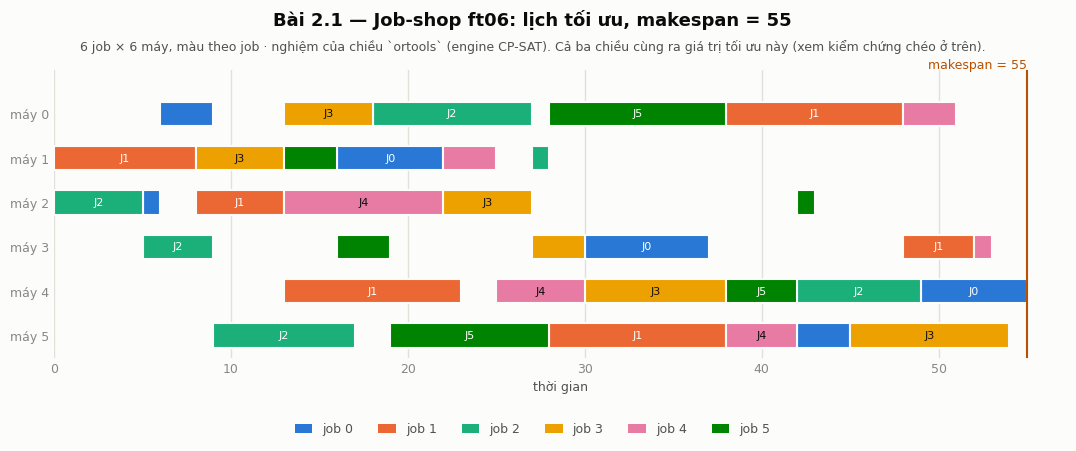

In [9]:
show_solution("2.1_jobshop")

## (d) Quan sát so sánh

In [10]:
show_notes("2.1_jobshop", "Quan sát")

## (d) Quan sát so sánh

Tất cả số liệu dưới đây đo trên cùng instance `ft06`, cùng máy, cùng lời giải tối
ưu **55**. Lệnh tái lập: `make run P=models/2.1_jobshop`.

### Kiểm chứng chéo — điều kiện cần trước mọi so sánh

| Chiều | Ngôn ngữ | Engine | Makespan | Trạng thái |
|---|---|---|---|---|
| `opl` | OPL | CP Optimizer | **55** | Optimal (đã chứng minh) |
| `docplexcp` | Python `docplex.cp` | CP Optimizer | **55** | Optimal (đã chứng minh) |
| `ortools` | Python `ortools.sat` | CP-SAT | **55** | OPTIMAL |

Cả ba khớp đúng giá trị tối ưu đã công bố của ft06. Thêm một chi tiết đáng chú ý:
hai chiều CP Optimizer trả về **cùng một lịch, từng con số trùng khít**:

```
5  6 16 30 42 49        <- OPL và DOcplex.cp cho ma trận start giống hệt nhau
0  8 13 28 38 48
0  5  9 18 27 38
8 13 22 27 30 45
13 22 25 38 48 52
13 16 19 28 45 49
```

Chiều OR-Tools ra **một lịch khác**, cùng makespan 55 — đúng như kỳ vọng: bài có
nhiều nghiệm tối ưu, hai engine duyệt theo hai thứ tự khác nhau nên chạm nghiệm
khác nhau. Đây là bằng chứng thêm rằng ba bản là ba cài đặt độc lập chứ không
phải chép của nhau.

### Số liệu

| Chiều | Ngôn ngữ | Engine | Obj | Thời gian giải | Nhánh | Fails / Conflicts |
|---|---|---|---|---|---|---|
| `opl` | OPL | CP Optimizer | 55 | 0,051 s | 140 843 | 4 636 |
| `docplexcp` | Python (docplex.cp) | CP Optimizer | 55 | 0,039 s | 141 455 | 4 653 |
| `ortools` | Python (ortools.sat) | CP-SAT | 55 | **0,011 s** | **219** | 3 |

Trung vị 3 lần chạy. Hai chiều CP Optimizer **tất định tuyệt đối** (ba lần chạy
ra đúng cùng số nhánh). Chiều CP-SAT chạy với `num_workers=1`, `random_seed=42`
để tái lập được — xem cảnh báo ở cuối mục.

---

### Trục NGÔN NGỮ — OPL vs DOcplex.cp (cùng engine CP Optimizer)

| | OPL | DOcplex.cp | chênh lệch |
|---|---|---|---|
| Nhánh | 140 843 | 141 455 | **+0,43 %** |
| Fails | 4 636 | 4 653 | +0,37 % |
| Thời gian giải | 0,051 s | 0,039 s | — |

**Kết luận: ở bài này, ngôn ngữ gần như KHÔNG ảnh hưởng gì.** Chênh lệch dưới nửa
phần trăm, và lời giải trả về trùng khít từng con số. Hai bản viết bằng hai ngôn
ngữ khác hẳn nhau nhưng **dịch xuống cùng một mô hình engine**.

Đối chiếu với **bài 1.2 N-Queens**, cũng cùng engine CP Optimizer:

| Bài | OPL (nhánh/fails) | DOcplex.cp (nhánh/fails) | Chênh |
|---|---|---|---|
| 1.2 N-Queens n=8 | 440 / 198 | 255 / 99 | **~73 %** |
| 2.1 Job-shop ft06 | 140 843 / 4 636 | 141 455 / 4 653 | **0,4 %** |

Hai kết quả trái ngược này **không mâu thuẫn** — chúng chỉ ra đúng điều kiện để
ngôn ngữ trở thành yếu tố quyết định:

> Ngôn ngữ chỉ làm đổi số liệu khi nó **ép ta viết một mô hình toán khác**.

Ở bài 1.2, `allDifferent` của OPL không nhận mảng biểu thức, nên bản OPL buộc
phải vật chất hoá hai đường chéo thành `dvar` phụ — **thêm 2n biến quyết định**,
tức engine nhận về một bài toán khác thật. Ở bài 2.1, mọi thứ OPL viết đều có
tương ứng một-một trong `docplex.cp`, không phải thêm biến nào, nên engine nhận
về **đúng cùng một bài**.

**Khác biệt cú pháp duy nhất đáng kể** ở bài này nằm ở `dvar sequence`:

```opl
// OPL — một câu lệnh: lọc theo điều kiện + gom nhóm + tạo biến thứ tự
dvar sequence mchs[m in Mchs] in all(j in Jobs, o in Mchs : Ops[j][o].mch == m) itvs[j][o];
forall (m in Mchs) noOverlap(mchs[m]);
```

```python
# DOcplex.cp — không có cú pháp khai báo tương ứng, phải gom nhóm bằng vòng lặp
machine_operations = [[] for m in range(NB_MACHINES)]
for j in range(NB_JOBS):
    for s in range(NB_MACHINES):
        machine_operations[MACHINES[j][s]].append(job_operations[j][s])
for mops in machine_operations:
    mdl.add(no_overlap(mops))
```

OPL có bộ **comprehension trên biến quyết định** (`all(... : điều kiện)`) ngay
trong ngôn ngữ, còn `sequence` là một **kiểu dữ liệu hạng nhất**. Bản Python phải
tự dựng danh sách. Nhưng — và đây mới là điểm — **cả hai đều sinh ra đúng một
ràng buộc `noOverlap` cho mỗi máy**, nên khác biệt dừng lại ở mức *dễ đọc / dễ
viết*, không lan xuống tới engine.

**Bẫy ngôn ngữ của bản DOcplex.cp.** Bản mẫu IBM mở đầu bằng
`from docplex.cp.model import *`, và lệnh này **che mất các hàm dựng sẵn của
Python**: `max`, `min`, `sum`, `abs`, `round` đều bị thay bằng hàm dựng *biểu
thức* của docplex. Trong khối mô hình đó chính là điều ta muốn —
`max(end_of(...) for ...)` phải sinh ra một `CpoExpr` chứ không phải tính ngay.
Nhưng ở phần đọc kết quả thì `round(t, 4)` báo lỗi
`TypeError: round() takes 1 positional argument but 2 were given`. Đây là thứ
**không thể xảy ra trong OPL**, nơi ngôn ngữ mô hình và ngôn ngữ script tách bạch.
Cái giá của việc nhúng ngôn ngữ mô hình vào một ngôn ngữ chủ (DSL nội sinh).

---

### Trục ENGINE — DOcplex.cp vs OR-Tools (cùng Python, cùng mã hoá interval)

| | CP Optimizer | CP-SAT | tỉ lệ |
|---|---|---|---|
| Nhánh | 141 455 | **219** | **645×** ít hơn |
| Fails / Conflicts | 4 653 | 3 | *(không so trực tiếp)* |
| Thời gian giải | 0,039 s | **0,011 s** | 3,5× nhanh hơn |
| Tốc độ duyệt | ~3,6 triệu nhánh/giây | ~20 nghìn nhánh/giây | ~180× chậm hơn mỗi nhánh |

Đây là **cặp số liệu đáng giá nhất của cả báo cáo**, vì hai bản Python đặt cạnh
nhau gần như ánh xạ một-một:

| docplex.cp | ortools.sat |
|---|---|
| `interval_var(size=d)` | `new_interval_var(start, d, end, name)` |
| `no_overlap(list)` | `add_no_overlap(list)` |
| `end_before_start(a, b)` | `add(start_b >= end_a)` |
| `minimize(max(end_of(...)))` | `add_max_equality(...)` + `minimize(...)` |

Cùng ngôn ngữ, cùng mô hình toán, cùng cách mã hoá — **chỉ khác engine**. Số liệu
vì thế đo đúng một thứ.

**Hai lối đi khác hẳn nhau, thấy rõ qua con số:**

- **CP Optimizer** duyệt **ồ ạt** với chi phí mỗi nhánh cực rẻ — 3,6 triệu
  nhánh/giây. Nó dùng 140 nghìn nhánh cho một bài 36 công đoạn, nhưng mỗi nhánh
  chỉ tốn ~0,28 µs.
- **CP-SAT** duyệt **cực ít** — 219 nhánh, 3 xung đột — vì mỗi lần đụng mâu thuẫn
  nó **học ra một mệnh đề** chặn vĩnh viễn cả một vùng không gian (CDCL /
  lazy clause generation). Đổi lại mỗi nhánh đắt hơn ~180 lần.

Ở ft06, cách của CP-SAT thắng rõ. Nhưng **không được suy rộng từ một instance**:
bảng benchmark bài 3.2 cho thấy thứ tự đảo ngược ở hai cấu hình lớn, nơi CP
Optimizer về trước 1,6–3,8× (xem [`models/3.2_timetable/NOTES.md`](../3.2_timetable/NOTES.md)).
Kết luận đúng phải là: **hai engine mạnh ở hai chế độ khác nhau**, và ft06 quá
nhỏ để phân định.

**Khác biệt nguyên thuỷ (primitive) giữa hai engine, thấy được ở bài này:**

1. **`end_before_start` — CP-SAT không có, và cũng không cần.** CP-SAT phơi
   `start` / `size` / `end` ra thành ba **biến nguyên thật**, nên precedence viết
   thẳng thành bất đẳng thức tuyến tính `add(start[j,o] >= end[j,o-1])`. CP
   Optimizer giấu interval sau một API riêng, bù lại bằng cả một **họ** ràng buộc
   thời gian (`endBeforeStart`, `startBeforeStart`, `endAtStart`, `startAtEnd`,
   `startBeforeEnd`…) cộng thêm khái niệm **interval vắng mặt** (optional interval)
   — thứ CP-SAT chỉ có dạng rút gọn qua `new_optional_interval_var`. Bài 3.2 đã
   cho thấy chỗ này tốn kém thế nào khi phải dựng tay bên CP-SAT.

2. **CP-SAT bắt buộc phải có HORIZON hữu hạn.** Mọi biến nguyên của CP-SAT phải
   khai báo miền đóng, nên bản OR-Tools phải tính $H=\sum p_{j,o}=197$ trước rồi
   mới dựng biến được. CP Optimizer không cần: miền mặc định của interval đã là
   $0..\texttt{INTERVAL\_MAX}$. Nhỏ nhưng là khác biệt kiến trúc thật — CP-SAT
   quy mọi thứ về mệnh đề Boolean nên phải biết trước kích thước bảng.

3. **`dvar sequence` không có bên CP-SAT.** Cả biến thứ tự lẫn các ràng buộc đi
   kèm nó (`first`, `last`, `before`, `previous`, sequence có setup time) đều là
   đặc sản CP Optimizer. Ở bài 2.1 điều đó chưa gây khó vì `add_no_overlap` là đủ,
   nhưng nếu bài có **thời gian setup phụ thuộc thứ tự** thì CP Optimizer khai
   báo một ma trận `noOverlap(seq, M)` là xong, còn CP-SAT phải dựng tay biến
   Boolean cho từng cặp.

**Cảnh báo về tính tái lập của CP-SAT.** Chạy cùng model với `--workers 8`, ba
lần liên tiếp cho:

| Lần | Nhánh | Conflicts | Thời gian |
|---|---|---|---|
| 1 | 165 | 13 | 0,016 s |
| 2 | **0** | **0** | 0,018 s |
| 3 | 183 | 1 | 0,018 s |

Lần thứ hai báo **0 nhánh** — một worker đã tìm ra và chứng minh nghiệm bằng
presolve trước khi worker nào kịp phân nhánh. Đây đúng hiện tượng `PLAN.md` §2.4
mô tả. Vì thế bản OR-Tools của bài này mặc định `num_workers=1`, `random_seed=42`;
mọi con số trong bảng trên đều tái lập được từng đơn vị.

> Nhắc lại: `fails` của CP Optimizer (số nhánh chết) và `conflicts` của CP-SAT
> (số mệnh đề xung đột học được) **đếm hai thứ khác nhau**, chỉ so được trong
> cùng một engine.

### Biểu đồ Gantt

![Gantt DOcplex.cp](../../results/jobshop_ft06_docplexcp.png)

![Gantt OR-Tools](../../results/jobshop_ft06_ortools.png)

Hai lịch khác nhau, cùng makespan 55. Nhìn vào biểu đồ thấy ngay vì sao chặn dưới
47 không đạt được: máy $M_5$ (tải 43) và job $J_1$ (tải 47) đều bị chèn khe hở —
$J_1$ không thể chạy liên tục vì các máy nó cần đang bận job khác, và $M_5$ không
thể chạy liên tục vì các job cần nó chưa tới lượt.

---

---

# Bài 2.2 — Xếp ca nhân sự có nguyện vọng (Employee / Shift Scheduling with shift requests)

## (a) Phát biểu bài toán

In [11]:
show_notes("2.2_employee", "Phát biểu")

## (a) Phát biểu bài toán

Một đơn vị vận hành liên tục — bệnh viện, trung tâm trực, nhà máy ba ca — cần lập
lịch trực cho một kỳ. Kỳ gồm **7 ngày**, mỗi ngày chia thành **3 ca** (Morning,
Evening, Night). Đơn vị có **5 nhân viên**.

Yêu cầu vận hành:

- **Không được bỏ trống ca.** Mỗi ca của mỗi ngày phải có **đúng một** người trực.
  Không thiếu (bỏ trống thì dịch vụ đứt), cũng không thừa (thừa thì trả lương vô ích).
- **Không ai trực hai ca trong cùng một ngày.** Mỗi người nhận **tối đa một** ca mỗi ngày.
- **Chia việc công bằng.** Toàn kỳ có $7\times 3=21$ suất trực chia cho 5 người, tức
  4,2 suất/người — không chia chẵn được. Vậy mỗi người phải nhận trong khoảng
  $\lfloor 21/5\rfloor=4$ đến $\lceil 21/5\rceil=5$ suất. Không ai được rảnh cả
  tuần trong khi người khác trực gấp đôi.

Ngoài ba yêu cầu cứng đó, mỗi nhân viên nộp **nguyện vọng** (shift request): danh
sách những ca cụ thể mà họ *muốn* được xếp — vì tiện đi lại, vì lịch học, vì thích
ca đêm. Nguyện vọng là **mong muốn, không phải ràng buộc**: không đáp ứng được thì
lịch vẫn hợp lệ. Trong bộ dữ liệu này mỗi người nộp 4 nguyện vọng, tổng cộng 20.

> **Mục tiêu: xếp một lịch hợp lệ đáp ứng được NHIỀU nguyện vọng nhất.**

Đây là bài toán **rostering** kinh điển, và cũng là dạng bài mà brief §1 xếp vào ô
"tổ hợp/boolean nặng": toàn bộ quyết định là 105 câu hỏi có/không độc lập nhau, ràng
buộc đều là ràng buộc **đếm** trên các biến 0/1, không có thời lượng, không có trục
thời gian liên tục, không có tài nguyên tích luỹ. Không một biến interval nào xuất
hiện — khác hẳn bài 2.1 (job-shop) và bài 3.2 (timetable).

---

## (b) Mô hình toán học

Mô hình dưới đây là **hợp đồng chung** mà cả ba chiều cùng cài đặt. Ba đoạn code ở mục (c) chỉ là ba cách diễn đạt đúng mô hình này.

In [12]:
show_notes("2.2_employee", "Mô hình toán")

## (b) Mô hình toán học — DÙNG CHUNG cho cả ba chiều

> Cả ba chiều `opl`, `docplexcp`, `ortools` cài đặt **đúng mô hình dưới đây**, trên
> **đúng một file dữ liệu** `data/employee/employee.dat`. Không chiều nào thêm hay
> bớt một ràng buộc nào. Nhờ vậy mọi chênh lệch số liệu ở mục (d) chỉ có thể đến từ
> ngôn ngữ mô hình hoá hoặc từ engine, không đến từ mô hình.

### Tập hợp

| Ký hiệu | Ý nghĩa | Bộ dữ liệu này |
|---|---|---|
| $\mathcal{E}$ | tập nhân viên | $\{E_1,\dots,E_5\}$, $N=\lvert\mathcal{E}\rvert=5$ |
| $\mathcal{D}$ | tập ngày trong kỳ | $\{\text{Mon},\dots,\text{Sun}\}$, $\lvert\mathcal{D}\rvert=7$ |
| $\mathcal{S}$ | tập ca trong một ngày | $\{\text{Morning},\text{Evening},\text{Night}\}$, $\lvert\mathcal{S}\rvert=3$ |
| $\mathcal{R}\subseteq\mathcal{E}\times\mathcal{D}\times\mathcal{S}$ | tập **nguyện vọng**: $(e,d,s)\in\mathcal{R}$ nghĩa là nhân viên $e$ muốn làm ca $s$ ngày $d$ | $\lvert\mathcal{R}\rvert=20$ |

Gọi **suất trực** là một cặp $(d,s)\in\mathcal{D}\times\mathcal{S}$ — một ca cụ thể
của một ngày cụ thể. Tổng số suất trong kỳ:

$$\Sigma \;=\; \lvert\mathcal{D}\rvert\cdot\lvert\mathcal{S}\rvert \;=\; 7\cdot 3 \;=\; 21$$

### Tham số

| Ký hiệu | Định nghĩa | Bộ dữ liệu này |
|---|---|---|
| $r_{e,d,s}$ | chỉ báo nguyện vọng: $r_{e,d,s}=\mathbb{1}\bigl[(e,d,s)\in\mathcal{R}\bigr]$ | ma trận $5\times7\times3$, 20 ô bằng 1 |
| $L_{\min}$ | tải tối thiểu mỗi người $=\bigl\lfloor \Sigma/N \bigr\rfloor$ | $\lfloor 21/5\rfloor = 4$ |
| $L_{\max}$ | tải tối đa mỗi người $=\bigl\lceil \Sigma/N \bigr\rceil$ | $\lceil 21/5\rceil = 5$ |

Bản gốc của Google lưu $r$ ở dạng **dày** — mảng lồng ba tầng gồm 105 số 0/1. File
`.dat` dùng chung ở đây lưu ở dạng **thưa** — liệt kê 20 bộ ba thuộc $\mathcal{R}$.
Hai cách đồng nhất về toán học ($r_{e,d,s}=1 \iff (e,d,s)\in\mathcal{R}$); bản thưa
đọc được bằng mắt và hợp với cách OPL mô tả quan hệ bằng tuple set. Đã đối chiếu
từng ô trong 105 ô để chắc chắn không sai lệch.

### Biến quyết định

| Biến | Miền | Số lượng | Ý nghĩa |
|---|---|---|---|
| $x_{e,d,s}$ | $\{0,1\}$ | $N\cdot\lvert\mathcal{D}\rvert\cdot\lvert\mathcal{S}\rvert = 5\cdot7\cdot3 = \mathbf{105}$ | $x_{e,d,s}=1 \iff$ nhân viên $e$ trực ca $s$ trong ngày $d$ |

Đây là **toàn bộ** biến quyết định của mô hình — không có biến phụ, không có biến
interval, không có biến nguyên. Không gian tìm kiếm là $2^{105}$, thoải mái dưới
trần $2^{1000}$ của CPLEX Studio Community Edition (log CP Optimizer xác nhận:
*"Maximization problem — 105 variables, 70 constraints"*).

Đặt **tải** của nhân viên $e$ — số suất trực người đó nhận trong cả kỳ:

$$\ell_e \;=\; \sum_{d\in\mathcal{D}}\ \sum_{s\in\mathcal{S}} x_{e,d,s}$$

### Ràng buộc

**(C1) Mỗi suất trực do đúng một người đảm nhiệm.** Không bỏ trống, không xếp thừa.

$$\sum_{e\in\mathcal{E}} x_{e,d,s} \;=\; 1
\qquad \forall\, d\in\mathcal{D},\ \forall\, s\in\mathcal{S}
\tag{C1}$$

$\lvert\mathcal{D}\rvert\cdot\lvert\mathcal{S}\rvert = 21$ ràng buộc.

**(C2) Mỗi người trực tối đa một ca mỗi ngày.**

$$\sum_{s\in\mathcal{S}} x_{e,d,s} \;\le\; 1
\qquad \forall\, e\in\mathcal{E},\ \forall\, d\in\mathcal{D}
\tag{C2}$$

$N\cdot\lvert\mathcal{D}\rvert = 35$ ràng buộc. Chú ý (C2) là **bất đẳng thức**, không
phải đẳng thức: có ngày một người không trực ca nào, và điều đó bắt buộc phải xảy ra
vì $\lvert\mathcal{D}\rvert=7 > L_{\max}=5$.

**(C3)–(C4) Cân bằng tải.**

$$\ell_e \;\ge\; L_{\min} \qquad \forall\, e\in\mathcal{E} \tag{C3}$$

$$\ell_e \;\le\; L_{\max} \qquad \forall\, e\in\mathcal{E} \tag{C4}$$

$2N = 10$ ràng buộc.

### Hàm mục tiêu

$$\boxed{\ \max\ \; Z \;=\; \sum_{e\in\mathcal{E}}\sum_{d\in\mathcal{D}}\sum_{s\in\mathcal{S}}
r_{e,d,s}\, x_{e,d,s}
\;\;=\;\; \sum_{(e,d,s)\in\mathcal{R}} x_{e,d,s} \ }$$

Hai vế bằng nhau vì $r_{e,d,s}=0$ triệt tiêu mọi hạng tử ngoài $\mathcal{R}$. Vế
trái là cách viết của bản Google (quét cả lưới 105 ô); vế phải chạy thẳng trên tuple
set thưa (20 hạng tử). Chiều `opl` và `docplexcp` dùng vế phải, chiều `ortools` giữ
nguyên vế trái của bản chính thức.

### Ba hệ quả rút ra được từ mô hình

Ba tính chất dưới đây suy trực tiếp từ (C1)–(C4), không cần solver. Chúng vừa giải
thích lời giải, vừa là công cụ kiểm chứng độc lập ở mục (d).

**① Tổng tải luôn cố định, và số người phải làm thêm ca là xác định trước.**
Cộng (C1) trên mọi suất:

$$\sum_{e\in\mathcal{E}} \ell_e \;=\; \sum_{d,s}\ \sum_{e} x_{e,d,s} \;=\; \Sigma \;=\; 21$$

Kết hợp với (C3)–(C4): nếu gọi $k$ là số nhân viên nhận $L_{\max}$ suất thì
$k\,L_{\max} + (N-k)L_{\min} = \Sigma$, suy ra

$$k \;=\; \Sigma - N\!\cdot\!L_{\min} \;=\; \Sigma \bmod N \;=\; 21 \bmod 5 \;=\; 1$$

Nghĩa là **đúng một** người nhận 5 suất, bốn người còn lại nhận 4 suất — biết trước
mà không cần giải. Cả ba chiều đều in ra đúng như vậy; đây là phép thử đầu tiên xem
bản cài đặt có trung thực không.

**② Ràng buộc cân bằng luôn khả thi.** Vì $N L_{\min}\le \Sigma\le N L_{\max}$ theo
đúng định nghĩa sàn/trần, (C3)–(C4) không bao giờ mâu thuẫn với (C1). Bài luôn có
nghiệm khả thi, nên mọi chiều bắt buộc phải trả về `Optimal`, không bao giờ
`Infeasible`.

**③ Chặn trên chặt của hàm mục tiêu — và ở bộ dữ liệu này nó CHÍNH LÀ tối ưu.**
Theo (C1), mỗi suất $(d,s)$ chỉ có một người trực, nên **mỗi suất đáp ứng được nhiều
nhất một nguyện vọng**, bất kể có bao nhiêu người cùng xin suất đó. Vậy

$$Z \;\le\; \Bigl\lvert\ \bigl\{\,(d,s)\;:\;\exists e,\ (e,d,s)\in\mathcal{R}\,\bigr\}\ \Bigr\rvert$$

Đếm trên bộ dữ liệu này: 20 nguyện vọng chỉ rơi vào **13 suất khác nhau** — 6 suất bị
tranh chấp, trong đó `<Sat, Evening>` có tới 3 người cùng xin (E1, E3, E5), còn
`<Mon,Night>`, `<Sun,Night>`, `<Wed,Evening>`, `<Thu,Evening>`, `<Fri,Morning>` mỗi
suất 2 người. Do đó

$$Z^\star \;\le\; 13$$

Cả ba chiều đều đạt $Z^\star = 13$ ⇒ **chặn trên khít, và 13 là tối ưu — chứng minh
được bằng tay, độc lập hoàn toàn với mọi solver.** Bảy nguyện vọng bị bỏ không phải
vì mô hình xếp kém, mà vì bảy người đó xin trùng suất với người khác; không lịch nào
đáp ứng nổi. (Chặn trên từ phía nhân viên — $\sum_e \min(\lvert\mathcal{R}_e\rvert,
L_{\max}, \#\text{ngày }e\text{ xin})$ — cho 20, tức là rất lỏng; chặn từ phía suất
mới là chặn có ích.)

---

## (c) Cài đặt ba chiều

### OPL → engine CP Optimizer

In [13]:
show_dimension_code("2.2_employee", "opl")

**OPL → engine CP Optimizer · ✍️ viết mới**

```opl
/* Bài 2.2 — Employee / Shift Scheduling có nguyện vọng | Chiều OPL (engine CP Optimizer)
 * ---------------------------------------------------------------------------
 * Nguồn: ✍️ VIẾT MỚI.
 *
 * IBM KHÔNG phát hành bản CP nào của bài xếp ca nhân sự. Ví dụ `nurses` đi kèm
 * CPLEX Studio 22.2 tồn tại, nhưng nó là bản **MILP chạy trên engine CPLEX**:
 *   - `nurses.mod` KHÔNG có dòng `using CP;` ⇒ rơi vào context CPLEX;
 *   - nó khai `dvar float+ NurseWorkTime[...]` — biến LIÊN TỤC, thứ context CP
 *     của OPL không nhận;
 *   - chính file `.oplproject` của IBM ghi: "Nurses Scheduling model, MIP".
 * Bằng chứng đầy đủ ở NOTES.md mục (c). Vì vậy file này viết mới hoàn toàn, lấy
 * mô hình của ví dụ chính thức Google OR-Tools làm phát biểu bài toán.
 *
 * Chạy:
 *   tools/oplrun.sh models/2.2_employee/opl/employee.mod data/employee/employee.dat
 *
 * GHI CHÚ NGÔN NGỮ (điểm so sánh với DOcplex.cp, CÙNG engine CP Optimizer)
 * ------------------------------------------------------------------------
 * 1. OPL đánh chỉ số mảng biến TRỰC TIẾP bằng phần tử của {string}:
 *        dvar boolean x[Employees][Days][Shifts];
 *    Một dòng khai báo này đưa cả 105 biến vào engine, ĐÚNG THỨ TỰ (e,d,s).
 *    Python không có kiểu "mảng đánh chỉ số bằng tập hợp", nên bản docplex.cp
 *    phải dựng dict {(e,d,s): binary_var} — và docplex chỉ đẩy biến xuống engine
 *    theo thứ tự chúng XUẤT HIỆN LẦN ĐẦU trong ràng buộc, không theo thứ tự tạo.
 *    Hệ quả đo được: cùng engine, cùng mô hình, khác số nhánh. Xem NOTES.md (d).
 *
 * 2. `req[e][d][s]` là THAM SỐ tính sẵn từ tuple set ShiftRequests bằng một biểu
 *    thức ngay trong phần khai báo. OPL cho định nghĩa mảng dữ liệu bằng công
 *    thức; Python phải viết vòng lặp.
 *
 * 3. Ràng buộc có NHÃN (ctOnePerShift, ctBalanceLow...). Nhãn là khái niệm của
 *    NGÔN NGỮ OPL, không phải của engine — nó phục vụ conflict/relaxation
 *    iterator. Hai chiều Python không có tương đương trực tiếp.
 *
 * 4. Khối `execute` KHÔNG đọc được `dexpr`. Cái bẫy ở đây: để in được giá trị
 *    mục tiêu, phản xạ tự nhiên là vật chất hoá nó thành một `dvar` phụ. Làm vậy
 *    thì mô hình đổi và số nhánh tăng ~40% (đo thật: 1 133 -> 1 583). Cách đúng
 *    là dùng `cp.getObjValue()` — không thêm biến nào. Xem NOTES.md (d).
 */

using CP;

{string} Employees = ...;
{string} Days      = ...;
{string} Shifts    = ...;

tuple requestT {
  string e;   // nhân viên
  string d;   // ngày
  string s;   // ca
}
{requestT} ShiftRequests = ...;

// --- tham số dẫn xuất -------------------------------------------------------
int nEmployees = card(Employees);
int nDays      = card(Days);
int nShifts    = card(Shifts);

// Tổng số suất phải phủ trong kỳ: mỗi ca mỗi ngày đúng một người.
int totalSlots = nDays * nShifts;

// Cân bằng tải: floor(DS/N) .. ceil(DS/N).
int minLoad = totalSlots div nEmployees;
int maxLoad = (totalSlots mod nEmployees == 0) ? minLoad : minLoad + 1;

// Ma trận nguyện vọng, tính sẵn từ tuple set thưa. req[e][d][s] = 1 nghĩa là
// nhân viên e MUỐN làm ca s ngày d — tương ứng shift_requests[n][d][s] của Google.
// Chỉ dùng để in lịch; hàm mục tiêu chạy thẳng trên tuple set thưa.
int req[e in Employees][d in Days][s in Shifts] =
  sum(<e2,d2,s2> in ShiftRequests : e2 == e && d2 == d && s2 == s) 1;

// --- cấu hình engine, để số liệu tái lập được và so được với hai chiều kia ---
// Khối execute đứng TRƯỚC phần mô hình sẽ chạy trước khi giải. Cả ba chiều đều
// chạy 1 worker + seed cố định; nếu không thì branches/fails đổi mỗi lần chạy
// và bảng so sánh trong NOTES.md mất giá trị (PLAN.md §2.4).
execute PARAMS {
  cp.param.workers = 1;
  cp.param.randomSeed = 0;
}

// --- biến quyết định --------------------------------------------------------
// x[e][d][s] = 1 <=> nhân viên e làm ca s trong ngày d.  (105 biến bool)
dvar boolean x[Employees][Days][Shifts];

// --- hàm mục tiêu: tối đa số nguyện vọng được đáp ứng ------------------------
// Tổng chạy thẳng trên TUPLE SET THƯA (20 hạng tử) thay vì quét cả lưới 105 ô
// nhân hệ số 0/1. Không có biến phụ nào.
maximize sum(<e,d,s> in ShiftRequests) x[e][d][s];

subject to {

  // (C1) mỗi ca của mỗi ngày do ĐÚNG một người đảm nhiệm
  forall(d in Days, s in Shifts)
    ctOnePerShift:
      sum(e in Employees) x[e][d][s] == 1;

  // (C2) mỗi người làm TỐI ĐA một ca mỗi ngày
  forall(e in Employees, d in Days)
    ctAtMostOneShiftPerDay:
      sum(s in Shifts) x[e][d][s] <= 1;

  // (C3) cân bằng tải — chặn dưới
  forall(e in Employees)
    ctBalanceLow:
      sum(d in Days, s in Shifts) x[e][d][s] >= minLoad;

  // (C4) cân bằng tải — chặn trên
  forall(e in Employees)
    ctBalanceHigh:
      sum(d in Days, s in Shifts) x[e][d][s] <= maxLoad;
}

// --- in lịch ----------------------------------------------------------------
execute POST_PROCESS {
  writeln("So nguyen vong duoc dap ung = ", cp.getObjValue(),
          " / ", ShiftRequests.size);
  for (var d in Days) {
    writeln("Ngay ", d);
    for (var s in Shifts) {
      for (var e in Employees) {
        if (x[e][d][s] == 1) {
          writeln("  ca ", s, "\t", e,
                  req[e][d][s] == 1 ? "\t(dung nguyen vong)" : "\t(khong xin)");
        }
      }
    }
  }
  writeln("Tai cua tung nhan vien (gioi han ", minLoad, "..", maxLoad, "):");
  for (var e in Employees) {
    var load = 0;
    for (var d in Days) for (var s in Shifts) load += x[e][d][s];
    writeln("  ", e, "\t", load, " ca");
  }
}

// --- dòng RESULT theo giao kèo của tools/runner.py --------------------------
// CHÚ Ý: card() không dùng được trong khối execute — phải dùng .size.
execute EMIT_RESULT {
  writeln("RESULT {\"status\":\"Optimal\""
        + ",\"objective\":" + cp.getObjValue()
        + ",\"solve_time_s\":" + cp.info.solveTime
        + ",\"branches\":" + cp.info.numberOfBranches
        + ",\"fails\":" + cp.info.numberOfFails
        + ",\"nb_employees\":" + Employees.size
        + ",\"nb_days\":" + Days.size
        + ",\"nb_shifts\":" + Shifts.size
        + ",\"nb_requests\":" + ShiftRequests.size
        + ",\"min_load\":" + minLoad
        + ",\"max_load\":" + maxLoad
        + ",\"nb_bool_vars\":" + (Employees.size * Days.size * Shifts.size) + "}");
}
```

### DOcplex.cp → engine CP Optimizer

In [14]:
show_dimension_code("2.2_employee", "docplexcp")

**Python (docplex.cp) → engine CP Optimizer · ✍️ viết mới**

```python
"""Bài 2.2 — Employee / Shift Scheduling có nguyện vọng | Chiều DOcplex.cp (engine CP Optimizer)

Nguồn: ✍️ VIẾT MỚI.

IBM KHÔNG phát hành bản CP nào của bài xếp ca nhân sự. Trong kho ví dụ chính thức
`IBMDecisionOptimization/docplex`, mọi file mang tên `nurses*` đều nằm dưới
`examples/mp/` và `docs/mp/` — nhánh **Math Programming** (`docplex.mp`, engine
CPLEX). Thư mục `examples/cp/` (107 file) không có lấy một file nào về xếp ca.
Xem NOTES.md mục (c) để có bằng chứng đầy đủ. File này vì thế viết mới hoàn toàn.

Đọc ĐÚNG file dữ liệu mà hai chiều kia dùng — `data/employee/employee.dat` — qua
`tools/opl_dat.py`, nên ba chiều không có bản dữ liệu riêng nào để lệch nhau.

Chạy:  python3 models/2.2_employee/docplexcp/employee_cp.py [data/employee/employee.dat]

VAI TRÒ CỦA CHIỀU NÀY TRONG BÁO CÁO
------------------------------------
Đây là điểm đo bản lề, tách bạch được hai nguyên nhân gây khác biệt:

    OPL         (CP Optimizer + ngôn ngữ OPL)
      ──vs── bản này (CP Optimizer + Python/docplex.cp)  → cô lập NGÔN NGỮ
      ──vs── OR-Tools (CP-SAT     + Python/ortools.sat)  → cô lập ENGINE

CHỖ CP-SAT CÓ MÀ CP OPTIMIZER KHÔNG CÓ
---------------------------------------
Bài này là bài BOOLEAN thuần: 105 biến 0/1, ba nhóm ràng buộc đếm. CP-SAT có sẵn
hai ràng buộc boolean toàn cục khớp đúng ý định:

    model.add_exactly_one(...)      # ortools
    model.add_at_most_one(...)

`docplex.cp` KHÔNG có tương đương ở tầng boolean — danh mục ràng buộc toàn cục
của CP Optimizer (all_diff, count, pack, sequence, no_overlap, alternative...)
hướng tới biến MIỀN RỜI RẠC và biến INTERVAL, không tới mệnh đề SAT. Nên ở đây
phải viết thành tổng SỐ HỌC trên biến 0/1:

    mdl.add(mdl.sum(x[e, d, s] for e in employees) == 1)

Đây là mặt trái của cùng một đồng xu đã thấy ở bài 3.2: ở đó CP Optimizer có
`alternative` và `forbid_extent` mà CP-SAT phải dựng tay; ở đây thì ngược lại.
Mỗi engine mạnh ở đúng lớp bài mà cấu trúc dữ liệu lõi của nó phục vụ.
"""

from __future__ import annotations

import json
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path(__file__).resolve().parents[3] / "tools"))
import cpo_env  # noqa: F401,E402  — trỏ docplex.cp sang cpoptimizer cục bộ
from opl_dat import load  # noqa: E402

from docplex.cp.model import CpoModel  # noqa: E402


def build_and_solve(dat_file: str, time_limit: float = 300.0,
                    workers: int = 1, seed: int = 0) -> dict:
    # ---- dữ liệu, đọc từ đúng file .dat dùng chung --------------------------
    d = load(dat_file)
    employees: list[str] = d["Employees"]
    days: list[str] = d["Days"]
    shifts: list[str] = d["Shifts"]
    requested = set(d["ShiftRequests"])          # tập bộ ba <e, d, s> được xin

    n_emp, n_days, n_shifts = len(employees), len(days), len(shifts)

    # Tổng số suất phải phủ trong kỳ, và khoảng cân bằng tải floor/ceil.
    total_slots = n_days * n_shifts
    min_load = total_slots // n_emp
    max_load = min_load if total_slots % n_emp == 0 else min_load + 1

    mdl = CpoModel(name="employee_shift_scheduling")

    # ---- biến quyết định ----------------------------------------------------
    # x[e, d, s] = 1 <=> nhân viên e làm ca s trong ngày d.
    # OPL viết được `dvar boolean x[Employees][Days][Shifts]` — mảng đánh chỉ số
    # thẳng bằng phần tử của {string}. Python không có kiểu đó, phải dựng dict.
    x = {
        (e, dd, s): mdl.binary_var(name=f"x_{e}_{dd}_{s}")
        for e in employees
        for dd in days
        for s in shifts
    }

    # ---- (C1) mỗi ca của mỗi ngày do ĐÚNG một người đảm nhiệm ---------------
    # Không có add_exactly_one như CP-SAT; diễn đạt bằng tổng số học.
    for dd in days:
        for s in shifts:
            mdl.add(mdl.sum(x[e, dd, s] for e in employees) == 1)

    # ---- (C2) mỗi người làm TỐI ĐA một ca mỗi ngày --------------------------
    for e in employees:
        for dd in days:
            mdl.add(mdl.sum(x[e, dd, s] for s in shifts) <= 1)

    # ---- (C3)-(C4) cân bằng tải --------------------------------------------
    for e in employees:
        load_e = mdl.sum(x[e, dd, s] for dd in days for s in shifts)
        mdl.add(load_e >= min_load)
        mdl.add(load_e <= max_load)

    # ---- mục tiêu: tối đa số nguyện vọng được đáp ứng -----------------------
    # Tổng chạy trên TẬP NGUYỆN VỌNG THƯA (20 hạng tử) thay vì trên toàn lưới
    # 105 ô nhân hệ số 0/1 — cùng một biểu thức toán, ít hạng tử hơn.
    mdl.add(mdl.maximize(mdl.sum(x[key] for key in requested)))

    sol = mdl.solve(TimeLimit=time_limit, Workers=workers, RandomSeed=seed,
                    LogVerbosity="Quiet")

    infos = sol.get_solver_infos() if sol else {}
    result = {
        "status": str(sol.get_solve_status()) if sol else "NoSolution",
        "objective": int(sol.get_objective_value()) if sol else None,
        "solve_time_s": round(sol.get_solve_time(), 4) if sol else None,
        "branches": infos.get("NumberOfBranches"),
        "fails": infos.get("NumberOfFails"),
        "nb_employees": n_emp,
        "nb_days": n_days,
        "nb_shifts": n_shifts,
        "nb_requests": len(requested),
        "min_load": min_load,
        "max_load": max_load,
        "nb_bool_vars": n_emp * n_days * n_shifts,
    }

    if sol:
        print(f"So nguyen vong duoc dap ung = {result['objective']} / {len(requested)}")
        for dd in days:
            print(f"Ngay {dd}")
            for s in shifts:
                for e in employees:
                    if sol[x[e, dd, s]] == 1:
                        tag = ("(dung nguyen vong)" if (e, dd, s) in requested
                               else "(khong xin)")
                        print(f"  ca {s:<8} {e}\t{tag}")
        print(f"Tai cua tung nhan vien (gioi han {min_load}..{max_load}):")
        for e in employees:
            load_e = sum(sol[x[e, dd, s]] for dd in days for s in shifts)
            print(f"  {e}\t{load_e} ca")

    return result


if __name__ == "__main__":
    dat = sys.argv[1] if len(sys.argv) > 1 else "data/employee/employee.dat"
    print("RESULT " + json.dumps(build_and_solve(dat)))
```

### OR-Tools → engine CP-SAT

In [15]:
show_dimension_code("2.2_employee", "ortools")

**Python (ortools.sat) → engine CP-SAT · ✅ mẫu chính thức**

```python
"""Bài 2.2 — Employee / Shift Scheduling có nguyện vọng | Chiều OR-Tools (engine CP-SAT)

Nguồn: ✅ LẤY MẪU CHÍNH THỨC.
  Google OR-Tools — "Employee scheduling / Scheduling with shift requests"
  https://developers.google.com/optimization/scheduling/employee_scheduling
  (bản `schedule_requests_sat.py`, Apache License 2.0)

Phần DỰNG MÔ HÌNH giữ nguyên như bản gốc của Google — cùng biến, cùng tên hàm
API, cùng thứ tự ràng buộc, cùng hàm mục tiêu. Chỉ bổ sung ba thứ:

  1. `shift_requests` đọc từ `data/employee/employee.dat` thay vì viết cứng
     trong code, để cả BA chiều dùng chung đúng một bộ dữ liệu. Bảng .dat là
     bản chép nguyên vẹn của mảng lồng trong ví dụ gốc (đã đối chiếu từng ô).
  2. Cố định `num_search_workers=1` và `random_seed` — CP-SAT chạy đa luồng thì
     `branches`/`conflicts` đổi giữa các lần chạy, số liệu sẽ không tái lập được
     (PLAN.md §2.4).
  3. Dòng `RESULT {json}` theo giao kèo của tools/runner.py.

Chạy:  python3 models/2.2_employee/ortools/employee_sat.py [data/employee/employee.dat]

GHI CHÚ ENGINE (điểm so sánh với DOcplex.cp, CÙNG ngôn ngữ Python)
------------------------------------------------------------------
CP-SAT có hai ràng buộc toàn cục viết thẳng được ý định của bài:

    model.add_exactly_one(...)     # mỗi ca đúng một người
    model.add_at_most_one(...)     # mỗi người tối đa một ca/ngày

Hai thứ này là ràng buộc BOOLEAN nguyên gốc: CP-SAT nạp chúng thành mệnh đề
SAT và lan truyền bằng bộ máy CDCL của chính nó. CP Optimizer không có API
tương đương ở tầng boolean — bản docplex.cp phải viết thành tổng số học
`sum(...) == 1` / `sum(...) <= 1`, tức là ràng buộc SỐ HỌC trên biến 0/1.
Đây đúng là loại bài mà brief §1 nói CP-SAT có sở trường.
"""

from __future__ import annotations

import json
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path(__file__).resolve().parents[3] / "tools"))
from opl_dat import load  # noqa: E402

from ortools.sat.python import cp_model  # noqa: E402


def read_instance(dat_file: str):
    """Đọc bộ dữ liệu dùng chung và dựng lại đúng mảng shift_requests của Google.

    File .dat lưu nguyện vọng ở dạng THƯA (danh sách bộ ba được yêu cầu, 20 phần
    tử). Hàm này bung ra dạng DÀY shift_requests[n][d][s] gồm 105 số 0/1 — đúng
    cấu trúc mà đoạn code gốc của Google mong đợi, nên phần dựng mô hình bên dưới
    không phải sửa một dòng nào.
    """
    d = load(dat_file)
    employees, days, shifts = d["Employees"], d["Days"], d["Shifts"]
    requested = set(d["ShiftRequests"])
    shift_requests = [
        [
            [1 if (employees[n], days[dd], shifts[s]) in requested else 0
             for s in range(len(shifts))]
            for dd in range(len(days))
        ]
        for n in range(len(employees))
    ]
    return employees, days, shifts, shift_requests


def build_and_solve(dat_file: str, workers: int = 1, seed: int = 0) -> dict:
    employees, day_names, shift_names, shift_requests = read_instance(dat_file)

    # ---- dựng mô hình: nguyên văn ví dụ chính thức của Google ---------------
    num_nurses = len(employees)
    num_shifts = len(shift_names)
    num_days = len(day_names)
    all_nurses = range(num_nurses)
    all_shifts = range(num_shifts)
    all_days = range(num_days)

    # Creates the model.
    model = cp_model.CpModel()

    # Creates shift variables.
    # shifts[(n, d, s)]: nurse 'n' works shift 's' on day 'd'.
    shifts = {}
    for n in all_nurses:
        for d in all_days:
            for s in all_shifts:
                shifts[(n, d, s)] = model.new_bool_var(f"shift_n{n}_d{d}_s{s}")

    # Each shift is assigned to exactly one nurse in .
    for d in all_days:
        for s in all_shifts:
            model.add_exactly_one(shifts[(n, d, s)] for n in all_nurses)

    # Each nurse works at most one shift per day.
    for n in all_nurses:
        for d in all_days:
            model.add_at_most_one(shifts[(n, d, s)] for s in all_shifts)

    # Try to distribute the shifts evenly, so that each nurse works
    # min_shifts_per_nurse shifts. If this is not possible, because the total
    # number of shifts is not divisible by the number of nurses, some nurses will
    # be assigned one more shift.
    min_shifts_per_nurse = (num_shifts * num_days) // num_nurses
    if num_shifts * num_days % num_nurses == 0:
        max_shifts_per_nurse = min_shifts_per_nurse
    else:
        max_shifts_per_nurse = min_shifts_per_nurse + 1
    for n in all_nurses:
        num_shifts_worked = 0
        for d in all_days:
            for s in all_shifts:
                num_shifts_worked += shifts[(n, d, s)]
        model.add(min_shifts_per_nurse <= num_shifts_worked)
        model.add(num_shifts_worked <= max_shifts_per_nurse)

    model.maximize(
        sum(
            shift_requests[n][d][s] * shifts[(n, d, s)]
            for n in all_nurses
            for d in all_days
            for s in all_shifts
        )
    )

    # Creates the solver and solve.
    solver = cp_model.CpSolver()
    # --- hết phần nguyên văn; dưới đây là cấu hình để tái lập số liệu --------
    solver.parameters.num_search_workers = workers
    solver.parameters.random_seed = seed
    status = solver.solve(model)

    ok = status in (cp_model.OPTIMAL, cp_model.FEASIBLE)
    if ok:
        print(
            f"So nguyen vong duoc dap ung = {int(solver.objective_value)}"
            f" / {sum(map(sum, (map(sum, r) for r in shift_requests)))}"
        )
        for d in all_days:
            print(f"Ngay {day_names[d]}")
            for s in all_shifts:
                for n in all_nurses:
                    if solver.value(shifts[(n, d, s)]) == 1:
                        tag = ("(dung nguyen vong)" if shift_requests[n][d][s]
                               else "(khong xin)")
                        print(f"  ca {shift_names[s]:<8} {employees[n]}\t{tag}")
        print(f"Tai cua tung nhan vien (gioi han {min_shifts_per_nurse}"
              f"..{max_shifts_per_nurse}):")
        for n in all_nurses:
            load_n = sum(solver.value(shifts[(n, d, s)])
                         for d in all_days for s in all_shifts)
            print(f"  {employees[n]}\t{load_n} ca")

        # Cấu trúc nghiệm cho phần vẽ hình (giao kèo SOLUTION của
        # tools/runner.py). Kèm ba danh sách tên nên lưới vẽ được mà không phải
        # đọc lại employee.dat; `requested` nói ô đó có đúng nguyện vọng không.
        print("SOLUTION " + json.dumps({
            "problem": "employee",
            "employees": employees,
            "days": day_names,
            "shifts": shift_names,
            "assignments": [
                {"employee": n, "day": d, "shift": s,
                 "requested": bool(shift_requests[n][d][s])}
                for d in all_days
                for s in all_shifts
                for n in all_nurses
                if solver.value(shifts[(n, d, s)]) == 1
            ],
            "nb_requests": sum(map(sum, (map(sum, r) for r in shift_requests))),
            "granted": int(solver.objective_value),
        }))

    return {
        "status": solver.status_name(status),
        "objective": int(solver.objective_value) if ok else None,
        "solve_time_s": round(solver.wall_time, 4),
        "branches": solver.num_branches,
        # CP-SAT đếm CONFLICT, CP Optimizer đếm FAIL — hai đại lượng khác nhau,
        # chỉ so trong cùng một engine (README).
        "fails": solver.num_conflicts,
        "nb_employees": num_nurses,
        "nb_days": num_days,
        "nb_shifts": num_shifts,
        "nb_requests": sum(map(sum, (map(sum, r) for r in shift_requests))),
        "min_load": min_shifts_per_nurse,
        "max_load": max_shifts_per_nurse,
        "nb_bool_vars": num_nurses * num_days * num_shifts,
    }


if __name__ == "__main__":
    dat = sys.argv[1] if len(sys.argv) > 1 else "data/employee/employee.dat"
    print("RESULT " + json.dumps(build_and_solve(dat)))
```

## Chạy — cả ba chiều, cùng một bộ dữ liệu

Bảng dưới sinh ra bằng cách **chạy thật** ba file code vừa in ở trên.

In [16]:
run_table("2.2_employee")

chiều,ngôn ngữ,engine,nguồn,trạng thái,mục tiêu,thời gian giải (s),nhánh,fails/conflicts
opl,OPL,CP Optimizer,✍️,Optimal,13,0.017,1133,354
docplexcp,Python (docplex.cp),CP Optimizer,✍️,Optimal,13,0.011,1325,418
ortools,Python (ortools.sat),CP-SAT,✅,OPTIMAL,13,0.0055,254,0


### Kiểm chứng chéo

Ba chiều phải cùng ra một nghiệm tối ưu. Không có bước này thì mọi so sánh hiệu năng đều vô nghĩa — nhanh hơn mà giải sai bài thì không nói lên điều gì.

In [17]:
cross_check("2.2_employee")

**Kiểm chứng chéo — bài 2.2_employee**

`opl` = 13 · `docplexcp` = 13 · `ortools` = 13 → ✅ **KHỚP** — các chiều cùng một nghiệm tối ưu


### Nghiệm tìm được

Hình dưới là **nghiệm của chiều `ortools`** (engine CP-SAT) — chiều duy nhất chạy được mà không cần giấy phép IBM, nên hình này dựng được trên mọi máy. Ba chiều vừa được kiểm chứng chéo ở ô ngay trên và **cùng ra một giá trị tối ưu** (13/20 nguyện vọng được đáp ứng), nên nghiệm vẽ dưới đây là một hiện thân cụ thể của đúng cái tối ưu mà cả ba chiều đạt tới.

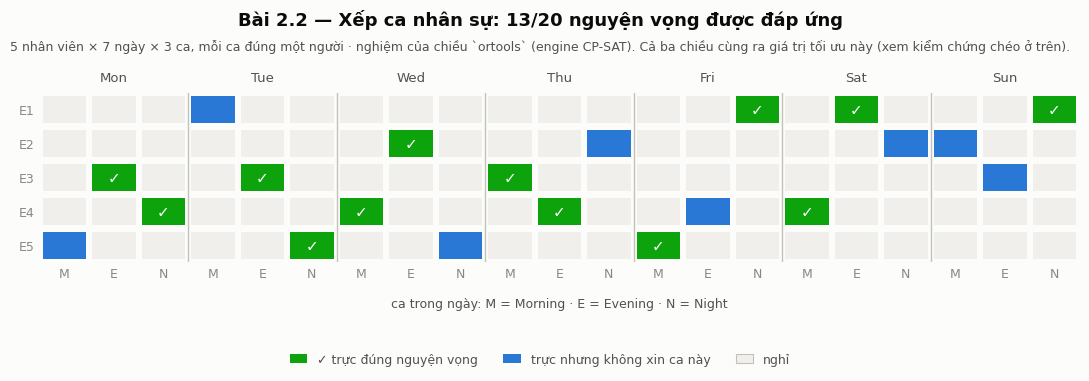

In [18]:
show_solution("2.2_employee")

## (d) Quan sát so sánh

In [19]:
show_notes("2.2_employee", "Quan sát")

## (d) Quan sát so sánh

### Kiểm chứng chéo — điều kiện tiên quyết

Ba chiều dựng độc lập, ba ngôn ngữ, hai engine, cùng một file dữ liệu:

| Chiều | Engine | Objective | Kết luận optimality |
|---|---|---|---|
| `opl` | CP Optimizer | **13** / 20 | `Optimal` (best bound = 13, gap 0.00%) |
| `docplexcp` | CP Optimizer | **13** / 20 | `Optimal` |
| `ortools` | CP-SAT | **13** / 20 | `OPTIMAL` |
| *chặn trên tính bằng tay* — mục (b)③ | — | **≤ 13** | khít |

Bốn nguồn độc lập cùng ra 13, trong đó nguồn thứ tư **không dùng solver nào**. Đây là
mức kiểm chứng chặt hơn hẳn bài 3.2 (chỉ đối chiếu solver với solver).

Ba chiều trả về **ba lịch khác nhau** — riêng ngày thứ Hai đã đủ phân biệt cả ba:

| Ca thứ Hai | `opl` | `docplexcp` | `ortools` |
|---|---|---|---|
| Morning | E2 | E2 | **E5** |
| Evening | E3 | E3 | E3 |
| Night | E4 | **E1** | E4 |

(người nhận 5 suất cũng lệch: E3, E3, E4). Đó là bình thường và đúng kỳ vọng: bài
có rất nhiều nghiệm tối ưu vì các nhân viên đối xứng với nhau ở mọi suất không ai xin.
Thứ phải trùng là **giá trị mục tiêu**, không phải lời giải cụ thể — và nó trùng.

Cả ba đều in đúng: một người 5 suất, bốn người 4 suất — khớp hệ quả ① ở mục (b).

### Số liệu — tất cả đều tái lập được

Cả ba chiều cố định **1 worker + seed 0** (PLAN.md §2.4). Chạy lại 3 lần: `branches`
và `fails` giống hệt từng con số, chỉ `solve_time_s` dao động ở hàng phần nghìn giây.

| Chiều | Ngôn ngữ | Engine | Obj | Thời gian giải | Nhánh | Fails / Conflicts |
|---|---|---|---|---|---|---|
| `opl` | OPL | CP Optimizer | 13 | 0,015 s | 1 133 | 354 |
| `docplexcp` | Python `docplex.cp` | CP Optimizer | 13 | 0,013 s | 1 325 | 418 |
| `ortools` | Python `ortools.sat` | CP-SAT | 13 | **0,0055 s** | **254** | **0** |

Quy mô: **105 biến bool**, không gian tìm kiếm $2^{105}$ — thoải mái dưới trần
$2^{1000}$ của Community Edition. Mô hình có $21+35+10=66$ ràng buộc theo (C1)–(C4);
log CP Optimizer báo `105 variables, 70 constraints` — chênh 4 là do bước trích xuất
của OPL, không phải do mô hình thêm ràng buộc nào.

> Nhắc lại quy ước của README: cột cuối là `fails` với CP Optimizer và `conflicts`
> với CP-SAT — **hai đại lượng đếm hai thứ khác nhau**, chỉ so được trong cùng một
> engine. Cột `branches` thì so được vì cả hai đều đếm điểm rẽ nhánh.

---

### Trục NGÔN NGỮ — OPL vs DOcplex.cp, cùng engine CP Optimizer

Cùng engine, cùng mô hình toán, cùng dữ liệu, cùng 1 worker và cùng seed. Mà:

| | OPL | DOcplex.cp | chênh |
|---|---|---|---|
| Nhánh | 1 133 | 1 325 | **+17 %** |
| Fails | 354 | 418 | +18 % |

**Nguyên nhân đã truy ra và kiểm chứng bằng thí nghiệm: thứ tự biến được nạp xuống
engine.**

OPL khai báo cả 105 biến trong **một dòng**, và thứ tự là thứ tự khai báo:

```opl
dvar boolean x[Employees][Days][Shifts];      // (e, d, s)
```

Python không có kiểu "mảng đánh chỉ số bằng tập hợp", nên `docplex.cp` phải dựng dict:

```python
x = {(e, dd, s): mdl.binary_var(name=f"x_{e}_{dd}_{s}") for e in employees for dd in days for s in shifts}
```

Dict được tạo theo thứ tự $(e,d,s)$ — nhưng **`docplex.cp` không nạp biến theo thứ tự
tạo**. Nó chỉ đẩy một biến xuống engine khi biến đó **xuất hiện lần đầu trong một ràng
buộc**. Ràng buộc đầu tiên là (C1), duyệt theo $(d,s)$ rồi mới tới $e$ — nên file `.cpo`
sinh ra bắt đầu bằng:

```
x_E1_Mon_Morning = intVar(0, 1);
x_E2_Mon_Morning = intVar(0, 1);      // <- thứ tự (d, s, e), KHÁC bản OPL
x_E3_Mon_Morning = intVar(0, 1);
```

Thứ tự biến là đầu vào của heuristic chọn biến mặc định của CP Optimizer, nên nó đổi
cây tìm kiếm. **Thí nghiệm xác nhận** — chỉ hoán vị thứ tự *post* ba nhóm ràng buộc
trong bản `docplex.cp`, không đổi một ký tự nào của mô hình toán:

| Thứ tự post ràng buộc | Thứ tự biến vào engine | Nhánh | Fails |
|---|---|---|---|
| C1 → C2 → C3 (bản đang dùng) | $(d,s,e)$ | 1 325 | 418 |
| C2 → C1 → C3 | $(e,d,s)$ — **trùng OPL** | **1 118** | 343 |
| C3 → C1 → C2 | $(e,d,s)$ — **trùng OPL** | **1 118** | 343 |
| *(chiều OPL để đối chiếu)* | $(e,d,s)$ | *1 133* | *354* |

Hễ ép `docplex.cp` nạp biến theo đúng thứ tự $(e,d,s)$ của OPL, con số tụt từ 1 325 về
1 118 — sát ngay bản OPL (1 133). Chênh lệch 17 % biến mất.

> **Kết luận trục ngôn ngữ.** Ở bài này hai ngôn ngữ diễn đạt được mô hình toán *y hệt
> nhau* — không như bài 1.2 nơi `allDifferent` của OPL từ chối mảng biểu thức và ép
> phải thêm biến phụ. Nhưng chúng vẫn không đưa **cùng một bài toán** xuống engine: OPL
> cố định thứ tự biến bằng câu lệnh khai báo, `docplex.cp` để thứ tự đó **rơi ra như
> tác dụng phụ của thứ tự viết ràng buộc**. Một lựa chọn mà lập trình viên Python không
> hề biết mình đang thực hiện lại đáng giá 17 % số nhánh. Đây là dạng khác biệt ngôn
> ngữ **tinh vi hơn** trường hợp N-Queens: ở đó ngôn ngữ chặn ta viết một thứ; ở đây
> ngôn ngữ vẫn cho viết đúng, chỉ âm thầm đổi thứ tự.

**Một cái bẫy nữa của OPL, đã đo được.** Khối `execute` của OPL **không đọc được
`dexpr`**. Muốn in giá trị mục tiêu vào dòng `RESULT`, phản xạ tự nhiên là vật chất hoá
mục tiêu thành một `dvar` phụ rồi `maximize` biến đó:

```opl
dvar int met in 0..card(ShiftRequests);
maximize met;
subject to { met == sum(<e,d,s> in ShiftRequests) x[e][d][s];  ... }
```

Chạy được, ra đúng 13 — nhưng **đắt hơn**:

| Bản OPL | Nhánh | Fails |
|---|---|---|
| `maximize` thẳng tổng thưa, đọc kết quả bằng `cp.getObjValue()` | **1 133** | **354** |
| thêm `dvar met` + ràng buộc `met == …` (tổng thưa) | 1 586 | 586 |
| thêm `dvar met` + ràng buộc `met == …` (tổng dày 105 ô) | 1 583 | 572 |

**+40 % số nhánh** cho một biến phụ tồn tại thuần tuý vì hạn chế của tầng scripting.
Hai dòng cuối gần như trùng nhau ⇒ thủ phạm là **biến phụ**, không phải cách viết tổng.
Bản giao nộp dùng `cp.getObjValue()` nên không phải trả giá này. Cùng một họ hiện tượng
với bài 1.2 (440 nhánh với biến phụ so với 255 khi không cần), và cùng một bài học:
**trong OPL, mọi thứ phải nhìn thấy từ `execute` đều có nguy cơ trở thành biến quyết
định, và biến quyết định thì không bao giờ miễn phí.**

---

### Trục ENGINE — DOcplex.cp vs OR-Tools, cùng ngôn ngữ Python

Cùng ngôn ngữ, cùng mô hình toán, cùng dữ liệu, cùng 1 worker và cùng seed:

| | DOcplex.cp / CP Optimizer | OR-Tools / CP-SAT | tỉ lệ |
|---|---|---|---|
| Thời gian giải | 0,013 s | **0,0055 s** | **2,4× nhanh hơn** |
| Nhánh | 1 325 | **254** | **5,2× ít hơn** |
| Fails / Conflicts | 418 | **0** | — |

**Con số đáng nói nhất là số 0.** CP-SAT chứng minh tối ưu mà **không quay lui lần
nào**: presolve + lan truyền mệnh đề đủ để đóng bài. 254 nhánh còn lại là các bước gán
không hề vấp. Trong khi đó CP Optimizer vấp 418 lần trên đúng bài đó.

Vì sao? Vì bài này là **bài boolean thuần**, và hai engine có hai bộ ràng buộc lõi khác nhau.

**CP-SAT có, CP Optimizer không có.** Hai ràng buộc trong (C1), (C2) chính là hai
nguyên hàm boolean của SAT:

```python
model.add_exactly_one(shifts[(n, d, s)] for n in all_nurses)   # (C1)
model.add_at_most_one(shifts[(n, d, s)] for s in all_shifts)   # (C2)
```

CP-SAT nạp thẳng chúng thành **mệnh đề CNF** và giao cho bộ máy CDCL của chính nó —
lan truyền đơn vị, học mệnh đề xung đột, nhảy lùi không thời gian. Đây là sân nhà.

`docplex.cp` **không có API tương đương ở tầng boolean**. Danh mục ràng buộc toàn cục
của CP Optimizer — `all_diff`, `count`, `pack`, `sequence`, `no_overlap`, `alternative`,
`forbid_extent` — hướng tới biến **miền rời rạc** và biến **interval**. Ràng buộc "đúng
một trong các biến bool này bằng 1" phải viết thành **tổng số học**:

```python
mdl.add(mdl.sum(x[e, dd, s] for e in employees) == 1)          # (C1)
mdl.add(mdl.sum(x[e, dd, s] for s in shifts) <= 1)             # (C2)
```

Engine nhận về một ràng buộc **số học tuyến tính trên biến $\{0,1\}$**, và lan truyền nó
bằng suy luận khoảng trên tổng chứ không bằng suy luận mệnh đề. Đúng đắn như nhau,
nhưng yếu hơn hẳn: nó không sinh ra được **lời giải thích cho xung đột**, nên không học
được gì từ 418 lần thất bại — mỗi lần vấp là phải quay lui thời gian, không tích luỹ.

**Đối chiếu ngược với bài 3.2 mới thấy hết ý nghĩa.** Ở đó, chính CP Optimizer là bên
có primitive mà CP-SAT thiếu — `alternative` để chọn tài nguyên, `forbid_extent` để khai
báo lịch bận không tốn một biến quyết định nào; CP-SAT phải bung tay thành literal hiện
diện và phép tuyển, và trên bộ `large` nó thua 0,67 s so với 2,52 s. Ở bài 2.2 thì
ngược hẳn chiều.

| | Bài 3.2 (interval, min makespan) | Bài 2.2 (boolean, max nguyện vọng) |
|---|---|---|
| Primitive quyết định | `alternative`, `forbid_extent`, `no_overlap` | `add_exactly_one`, `add_at_most_one` |
| Bên có sẵn primitive | **CP Optimizer** | **CP-SAT** |
| Bên phải dựng tay | CP-SAT (literal hiện diện, phép tuyển) | CP Optimizer (tổng số học) |
| Bên thắng, bộ lớn nhất | CP Optimizer (0,67 s vs 2,52 s) | **CP-SAT (0,0055 s vs 0,013 s; 0 xung đột)** |

> **Kết luận trục engine.** Số liệu **xác nhận** nhận định của brief §1: bài tổ hợp /
> boolean nặng là sở trường của CP-SAT, và ở đây nó thắng ở cả ba cột — nhanh hơn 2,4×,
> ít nhánh hơn 5,2×, và không quay lui lần nào. Nhưng kết luận đúng **không phải**
> "CP-SAT mạnh hơn CP Optimizer". Đặt bài 2.2 cạnh bài 3.2 thì thấy rõ: mỗi engine
> thắng đúng ở lớp bài mà **cấu trúc dữ liệu lõi của nó phục vụ** — CDCL trên mệnh đề
> với CP-SAT, thuật toán lan truyền trên interval với CP Optimizer. Và điều đó khớp
> chính xác với thứ tìm được ở mục (c): IBM không thèm phát hành ví dụ CP cho bài xếp
> ca boolean, còn Google lại lấy chính nó làm bài hướng dẫn đầu bảng. **Chỗ trống trong
> kho ví dụ và chỗ yếu trong số liệu benchmark chỉ về cùng một hướng.**

**Cảnh báo về quy mô.** Bộ dữ liệu này rất nhỏ (105 biến, cả ba chiều xong dưới 20 ms),
nên tỉ lệ 2,4× đo trên thang phần nghìn giây, đủ để nêu xu hướng nhưng không nên ngoại
suy. Điểm vững chắc và không phụ thuộc quy mô là **0 conflicts** so với **418 fails**:
đó là khác biệt về *cách chứng minh tối ưu*, không phải về tốc độ đồng hồ. Bài duy nhất
có benchmark định lượng đầy đủ trong báo cáo vẫn là 3.2 (PLAN.md §1).

---